In [2]:
import pandas as pd

In [3]:
data = pd.read_csv("Laptop_price.csv")

In [4]:
data.head()

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Storage_Capacity  1000 non-null   int64  
 4   Screen_Size       1000 non-null   float64
 5   Weight            1000 non-null   float64
 6   Price             1000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 54.8+ KB


In [6]:
data.shape

(1000, 7)

In [7]:
data["Brand"].unique()

array(['Asus', 'Acer', 'Lenovo', 'HP', 'Dell'], dtype=object)

In [8]:
data.isna().sum()

Brand               0
Processor_Speed     0
RAM_Size            0
Storage_Capacity    0
Screen_Size         0
Weight              0
Price               0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data.describe()

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.750611,15.500000,584.576000,14.056790,3.466919,19604.187963
std,0.731796,10.988665,313.438517,1.705882,0.866541,9406.064880
min,1.511580,4.000000,256.000000,11.012111,2.000560,8570.012950
25%,2.089246,8.000000,256.000000,12.635523,2.717211,10114.012948
50%,2.760885,16.000000,512.000000,14.099643,3.464630,17287.241878
75%,3.362610,32.000000,1000.000000,15.528590,4.212583,31566.214754
max,3.998534,32.000000,1000.000000,16.985737,4.990728,33503.935037


In [11]:
numeric_data = data.select_dtypes(include=["number"])

In [12]:
numeric_data.corr()

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
Processor_Speed,1.000000,0.021391,-0.067576,-0.013425,-0.054603,-0.050737
RAM_Size,0.021391,1.000000,0.002111,-0.036002,-0.025382,0.061237
Storage_Capacity,-0.067576,0.002111,1.000000,-0.027560,0.041335,0.997908
Screen_Size,-0.013425,-0.036002,-0.027560,1.000000,0.021995,-0.026740
Weight,-0.054603,-0.025382,0.041335,0.021995,1.000000,0.038417
Price,-0.050737,0.061237,0.997908,-0.026740,0.038417,1.000000


In [13]:
import matplotlib.pyplot as plt

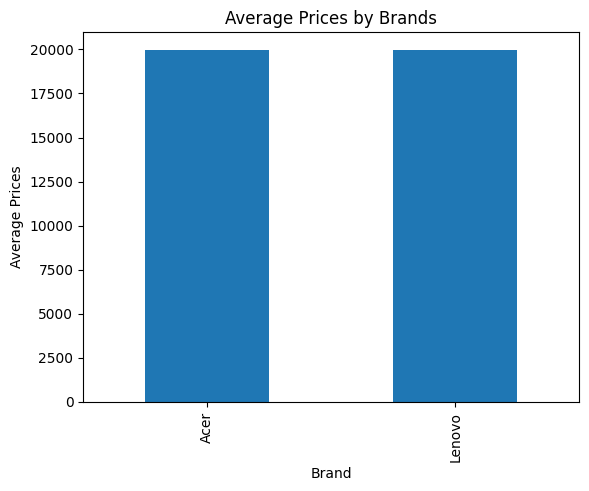

In [14]:
data.groupby("Brand")["Price"].mean().sort_values(ascending= False).head(2).plot(kind="bar")
plt.title("Average Prices by Brands")
plt.ylabel("Average Prices")
plt.show()

In [15]:
data.groupby("RAM_Size")["Brand"].value_counts().reset_index()

,RAM_Size,Brand,count
0,4,HP,59
1,4,Acer,50
2,4,Dell,48
3,4,Asus,47
4,4,Lenovo,39
5,8,Asus,66
6,8,Lenovo,51
7,8,Acer,48
8,8,Dell,43
9,8,HP,38


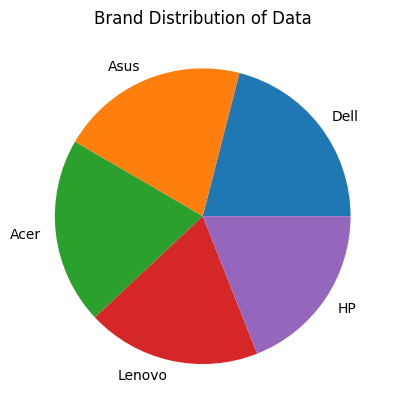

In [16]:
data["Brand"].value_counts().sort_values(ascending=False).plot(kind="pie")
plt.title("Brand Distribution of Data")
plt.ylabel("")
plt.show()

In [17]:
data.columns

Index(['Brand', 'Processor_Speed', 'RAM_Size', 'Storage_Capacity',
       'Screen_Size', 'Weight', 'Price'],
      dtype='object')

In [18]:
y = data["Price"]
X = data[["Processor_Speed", "RAM_Size", "Storage_Capacity"]]

In [19]:
X

,Processor_Speed,RAM_Size,Storage_Capacity
0,3.830296,16,512
1,2.912833,4,1000
2,3.241627,4,256
3,3.806248,16,512
4,3.268097,32,1000
...,...,...,...
995,3.343584,4,1000
996,2.780555,8,256
997,3.200569,4,512
998,1.604182,8,256


In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train , X_test , y_train , y_test = train_test_split(X,y, test_size=0.2)

In [22]:
len(X_train)

800

In [23]:
from sklearn.ensemble import RandomForestRegressor

In [24]:
rfrmodel = RandomForestRegressor()

In [25]:
from sklearn.model_selection import GridSearchCV

In [26]:
param_gridrfr = {"max_depth" : [2,5,10,15,20,25],
                 "max_features" : ["auto", "log2"],
                "n_estimators" : [2,4,6,8,10,12],}

In [27]:
gridrfr = GridSearchCV(rfrmodel, param_gridrfr)

In [28]:
gridrfr.fit(X_train,y_train)

c:\Users\ARNAV\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
180 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
180 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ARNAV\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ARNAV\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'max_depth': [2, 5, 10, 15, 20, 25],
                         'max_features': ['auto', 'log2'],
                         'n_estimators': [2, 4, 6, 8, 10, 12]})

In [29]:
gridrfr.best_params_

{'max_depth': 10, 'max_features': 'log2', 'n_estimators': 12}

In [30]:
predictions = gridrfr.predict(X_test)

In [31]:
from sklearn.metrics import mean_absolute_error

In [32]:
mean_absolute_error(y_test, predictions)

388.5280880234613

In [33]:
data["Price"].describe()

count     1000.000000
mean     19604.187963
std       9406.064880
min       8570.012950
25%      10114.012948
50%      17287.241878
75%      31566.214754
max      33503.935037
Name: Price, dtype: float64

In [34]:
X

,Processor_Speed,RAM_Size,Storage_Capacity
0,3.830296,16,512
1,2.912833,4,1000
2,3.241627,4,256
3,3.806248,16,512
4,3.268097,32,1000
...,...,...,...
995,3.343584,4,1000
996,2.780555,8,256
997,3.200569,4,512
998,1.604182,8,256


In [35]:
X.columns

Index(['Processor_Speed', 'RAM_Size', 'Storage_Capacity'], dtype='object')

In [36]:
gridrfr

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'max_depth': [2, 5, 10, 15, 20, 25],
                         'max_features': ['auto', 'log2'],
                         'n_estimators': [2, 4, 6, 8, 10, 12]})

In [37]:
import joblib

joblib.dump(gridrfr,"rf_model.pkl")

['rf_model.pkl']